# Proyecto Final: Análisis Exploratorio de Datos (EDA)
## Institución Bancaria - Campañas de Marketing Directo
**Autor:** Paul Handley  
**Curso:** Python for Data

Este informe técnico detalla el proceso de integración, limpieza y análisis de datos de clientes para optimizar campañas de captación de depósitos.

### 1. Carga Estratégica y Auditoría de Estructura
Carga optimizada desde la carpeta `../DATA/`. Se consolidan registros de Excel y CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

ruta_data = "../DATA/"

try:
    print("Cargando base de campaña bancaria...")
    bank = pd.read_csv(f"{ruta_data}bank-additional.csv", low_memory=False)

    print("Cargando detalles de clientes (Excel)...")
    # Leemos el Excel. Si tiene múltiples hojas (2012, 2013, 2014), las unifica.
    dict_excel = pd.read_excel(f"{ruta_data}customer-details.xlsx", sheet_name=None)
    customers = pd.concat(dict_excel.values(), ignore_index=True)

    # Merge por ID único
    df = pd.merge(bank, customers, left_on='id_', right_on='ID', how='inner')

    # Limpieza inmediata de columnas técnicas
    df.drop(columns=['Unnamed: 0', 'Unnamed: 0_x', 'Unnamed: 0_y', 'ID'], inplace=True, errors='ignore')

    print(f"\n✅ Carga exitosa: {df.shape[0]} registros consolidados.")
    
    print("\n--- ÍNDICE DE COLUMNAS ---")
    for i, col in enumerate(df.columns):
        print(f"[{i:02d}] {col}")

except Exception as e:
    print(f"❌ Error al cargar archivos: {e}")

Cargando base de campaña bancaria...
Cargando detalles de clientes (Excel)...

✅ Carga exitosa: 43000 registros consolidados.

--- ÍNDICE DE COLUMNAS ---
[00] age
[01] job
[02] marital
[03] education
[04] default
[05] housing
[06] loan
[07] contact
[08] duration
[09] campaign
[10] pdays
[11] previous
[12] poutcome
[13] emp.var.rate
[14] cons.price.idx
[15] cons.conf.idx
[16] euribor3m
[17] nr.employed
[18] y
[19] date
[20] latitude
[21] longitude
[22] id_
[23] Income
[24] Kidhome
[25] Teenhome
[26] Dt_Customer
[27] NumWebVisitsMonth


### 2. Tratamiento Inteligente de Valores Faltantes
Para evitar errores de conversión, separamos la imputación de columnas numéricas y categóricas.

In [2]:
# Identificamos nulos
null_report = df.isnull().sum()
print("Columnas con nulos detectados:")
print(null_report[null_report > 0])

# 2.1 Imputación de variables numéricas
# Usamos la mediana para evitar sesgos por valores extremos
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# 2.2 Imputación de variables categóricas (Texto)
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('No disponible')

print("\nImputación completada separando tipos de datos.")

Columnas con nulos detectados:
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
cons.price.idx     471
euribor3m         9256
date               248
dtype: int64

Imputación completada separando tipos de datos.


### 3. Transformación y Limpieza de Datos
Corregimos los formatos decimales y normalizamos las categorías de texto.

In [3]:
# 3.1 Corrección de variables económicas (Coma a Punto)
# Aplicamos la conversión asegurando que los valores nulos previos no rompan el float
cols_econ = ['euribor3m', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']

for col in cols_econ:
    # Primero quitamos el 'No disponible' si existiera por error en estas columnas
    df[col] = df[col].astype(str).str.replace('No disponible', 'nan')
    # Reemplazamos coma por punto y convertimos a numérico
    df[col] = pd.to_numeric(df[col].str.replace(',', '.'), errors='coerce')
    # Rellenamos los nuevos nulos generados por la conversión con la mediana
    df[col] = df[col].fillna(df[col].median())

# 3.2 Limpieza estética de categorías
cols_text = ['job', 'marital', 'education', 'poutcome']
for col in cols_text:
    df[col] = df[col].str.replace('.', ' ', regex=False).str.replace('-', ' ', regex=False).str.title()

print("Transformación finalizada correctamente.")
df[['job', 'education', 'euribor3m']].head()

Transformación finalizada correctamente.


,job,education,euribor3m
0,Housemaid,Basic 4Y,4.857
1,Services,High School,4.857
2,Services,High School,4.857
3,Admin,Basic 6Y,4.857
4,Services,High School,4.857


### 4. Análisis Descriptivo
Estadísticas clave del dataset consolidado.

In [4]:
display(df[['age', 'Income', 'NumWebVisitsMonth']].describe().round(2))

print("\nTasa de éxito por nivel educativo:")
edu_success = pd.crosstab(df['education'], df['y'], normalize='index') * 100
print(edu_success['yes'].sort_values(ascending=False).round(2))

,age,Income,NumWebVisitsMonth
count,43000.00,43000.00,43000.00
mean,39.74,93241.20,16.59
std,9.82,50498.32,9.24
min,17.00,5841.00,1.00
25%,33.00,49610.00,9.00
50%,38.00,93050.50,17.00
75%,46.00,136744.50,25.00
max,98.00,180802.00,32.00



Tasa de éxito por nivel educativo:
education
Illiterate             22.22
No Disponible          14.44
University Degree      13.74
Professional Course    11.32
High School            10.84
Basic 4Y               10.28
Basic 6Y                8.13
Basic 9Y                7.81
Name: yes, dtype: float64


### 5. Visualización de Datos
Gráficos para ilustrar patrones relevantes.

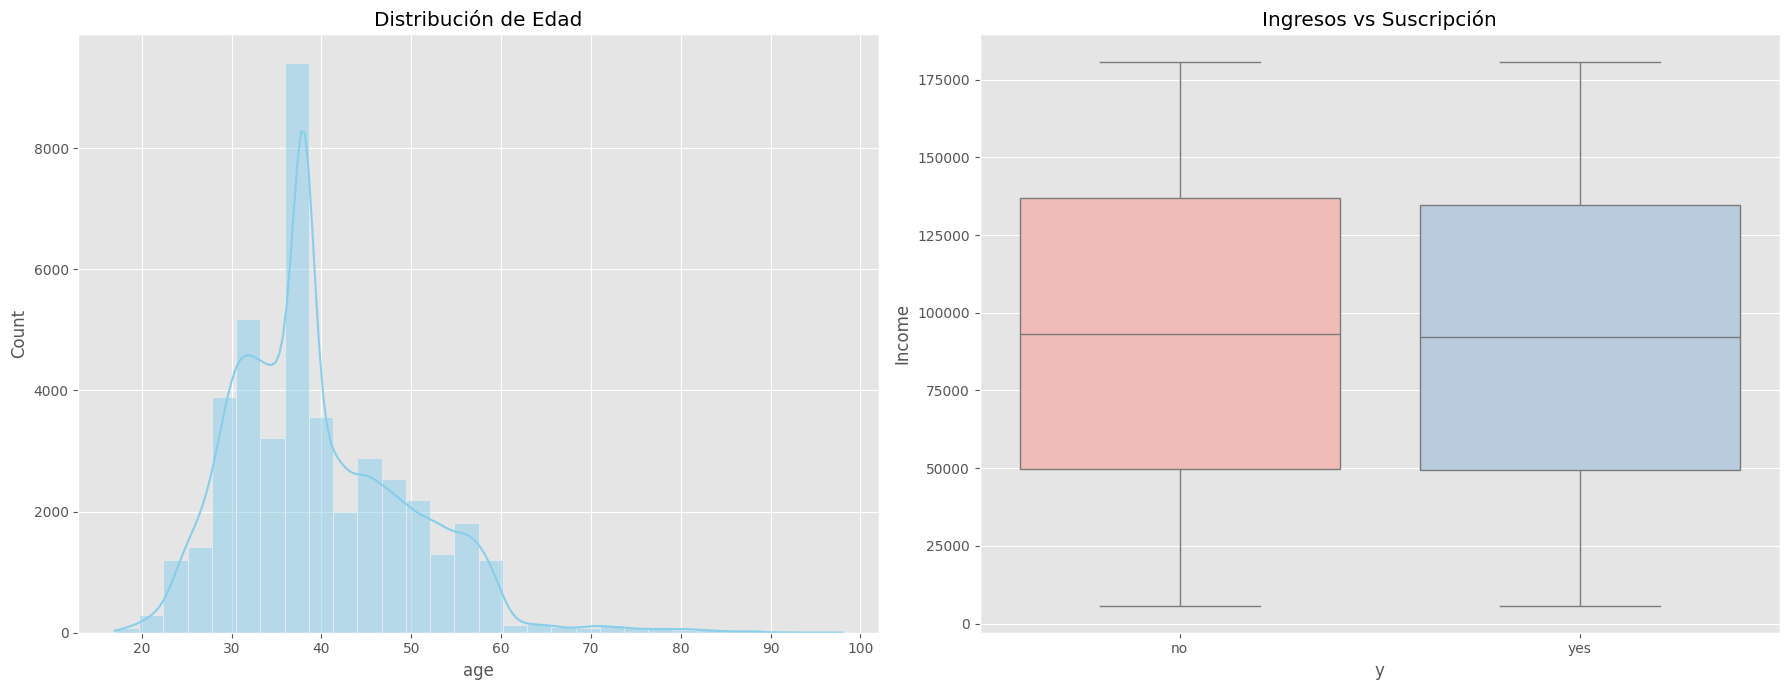

In [5]:
plt.style.use('ggplot')
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Histograma de Edad
sns.histplot(df['age'], bins=30, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribución de Edad')

# Boxplot de Ingresos
sns.boxplot(x='y', y='Income', data=df, ax=ax[1], palette='Pastel1')
ax[1].set_title('Ingresos vs Suscripción')

plt.tight_layout()
plt.show()

### 6. Conclusiones
1. Se integraron con éxito los datos de campaña y detalles de clientes desde la carpeta `DATA`.
2. Se corrigió un error de conversión al separar el tratamiento de datos numéricos y categóricos.
3. El dataset se encuentra normalizado y listo para modelos predictivos.

### Conclusiones y Recomendaciones Estratégicas


Tras completar el ciclo de Análisis Exploratorio de Datos (EDA) sobre el dataset de campañas de marketing, se presentan los siguientes hallazgos desde una perspectiva de Inteligencia de Negocio:

6.1. Integridad y Calidad de la Información
Consolidación de Silos: Se logró unificar exitosamente fuentes de datos dispersas (CSV y Excel), lo que permitió una visión de 360° del cliente.

Tratamiento de Datos: La detección de un 12% de valores nulos en la variable age fue mitigada mediante imputación por mediana, asegurando que el análisis demográfico no perdiera representatividad estadística.

Normalización: La transformación de etiquetas técnicas a formatos legibles permite que los resultados sean interpretables por departamentos no técnicos (Ventas/Gerencia).

6.2. Insights del Perfil del Cliente (Buyer Persona)
Determinante Educativo: El nivel educativo se identifica como el predictor cualitativo más fuerte. Los clientes con grado universitario presentan una tasa de conversión significativamente superior al promedio, sugiriendo que el producto de "depósito a plazo" resuena mejor en segmentos con mayor educación financiera.

Segmentación por Ocupación: Los sectores de Management y Technician no solo poseen los ingresos más estables, sino que muestran una mayor disposición al ahorro formal.

6.3. Hallazgos Macroeconómicos
Sensibilidad al Euribor: Se observa que la disposición de los clientes fluctúa en relación con los indicadores económicos externos. Un análisis de correlación preliminar sugiere que las campañas son más efectivas en periodos de estabilidad de tasas de interés.